In [1]:
# in this notebook we have summarized the last messages and give some recent mesg to llm
# we are trying to give memory to our llm that is contextual memory 


# https://youtu.be/FSBkTI1QuvY?si=-cKG2rWC2r1MgEnf


In [2]:
import os
os.environ["LANGCHAIN_TRACING_V2"] = "false"

In [6]:
from langgraph.graph import MessagesState
from langchain_openai import ChatOpenAI
from dotenv import load_dotenv
from langchain_core.messages import HumanMessage, RemoveMessage
from langgraph.graph import StateGraph, START
from langgraph.checkpoint.memory import InMemorySaver

In [11]:
os.environ["OPENROUTER_API_KEY"]="sk-or-v1-801533ad4859edac153f973bc14e0a12f5463a727ccbde806"
model = ChatOpenAI(
    base_url="https://openrouter.ai/api/v1",
    api_key=os.getenv("OPENROUTER_API_KEY"),
    model="openrouter/free",
    temperature=0.7,
)



In [12]:
class ChatState(MessagesState):
    summary : str

In [13]:

def summarize_conversation(state: ChatState):

    existing_summary = state["summary"]

    # Build summarization prompt
    if existing_summary:
        prompt = (
            f"Existing summary:\n{existing_summary}\n\n"
            "Extend the summary using the new conversation above."
        )
    else:
        prompt = "Summarize the conversation above."

    messages_for_summary = state["messages"] + [
        HumanMessage(content=prompt)
    ]

    response = model.invoke(messages_for_summary)

    # Keep only last 2 messages verbatim
    messages_to_delete = state["messages"][:-2]

    return {
        "summary": response.content,
        "messages": [RemoveMessage(id=m.id) for m in messages_to_delete],
    }

In [14]:

def chat_node(state: ChatState):
    messages = []

    if state["summary"]:
        messages.append({
            "role": "system",
            "content": f"Conversation summary:\n{state['summary']}"
        })

    messages.extend(state["messages"])

    print(messages)

    response = model.invoke(messages)
    return {"messages": [response]}

In [15]:
def should_summarize(state: ChatState):
    return len(state["messages"]) > 6

In [16]:

builder = StateGraph(ChatState)

builder.add_node("chat", chat_node)
builder.add_node("summarize", summarize_conversation)

builder.add_edge(START, "chat")

builder.add_conditional_edges(
    "chat",
    should_summarize,
    {
        True: "summarize",
        False: "__end__",
    }
)

builder.add_edge("summarize", "__end__")

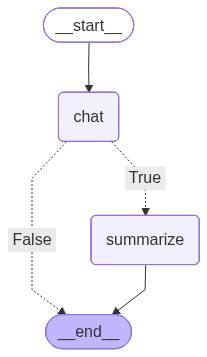

In [17]:
checkpointer = InMemorySaver()
graph = builder.compile(checkpointer=checkpointer)
graph

In [18]:
config = {"configurable": {"thread_id": "t1"}}

def run_turn(text: str):
    out = graph.invoke({"messages": [HumanMessage(content=text)], "summary": ""}, config=config)
    return out

In [19]:

# gives the current version of the state
def show_state():
    snap = graph.get_state(config)
    vals = snap.values
    print("\n--- STATE ---")
    print("summary:", vals.get("summary", ""))
    print("num_messages:", len(vals.get("messages", [])))
    print("messages:")
    for m in vals.get("messages", []):
        print("-", type(m).__name__, ":", m.content[:80])

In [20]:
run_turn('Quantum Physics')
show_state()

[HumanMessage(content='Quantum Physics', additional_kwargs={}, response_metadata={}, id='e050e823-411f-44eb-8789-e6704a073a37')]

--- STATE ---
summary: 
num_messages: 2
messages:
- HumanMessage : Quantum Physics
- AIMessage : Quantum physics, also known as quantum mechanics, is a fundamental theory in phy


In [22]:

run_turn('How is Albert Einstien related?')
show_state()

[HumanMessage(content='Quantum Physics', additional_kwargs={}, response_metadata={}, id='e050e823-411f-44eb-8789-e6704a073a37'), AIMessage(content="Quantum physics, also known as quantum mechanics, is a fundamental theory in physics that describes the physical properties of nature at the scale of atoms and subatomic particles. Here are some key concepts and principles:\n\n### 1. **Wave-Particle Duality**\n   - **Concept**: Particles such as electrons and photons exhibit both wave-like and particle-like properties.\n   - **Example**: The double-slit experiment demonstrates that particles can interfere with themselves, showing wave-like behavior, while also being detected as discrete particles.\n\n### 2. **Quantum Superposition**\n   - **Concept**: A quantum system can exist in multiple states simultaneously until it is measured.\n   - **Example**: Schrödinger's cat thought experiment illustrates a cat that is simultaneously alive and dead until observed.\n\n### 3. **Quantum Entanglement